# Caracteristicas musicales


A lo largo de este documento, se analizaran las relaciones existentes entre las dirferentes caracteristicas musicales que posee el dataset, asi mismo, se intentara dar una respuesta a las preguntas:

1. ¿Existen grupos naturales de canciones con características similares?
2. ¿Qué características presentan las correlaciones más fuertes?
3. ¿Las canciones con alta danceability también suelen tener alta energy?
4 ¿Existe relación entre valence (positividad emocional) y popularidad?
5. ¿Qué variables explican mejor la variabilidad musical del conjunto de datos?
6. ¿Es posible identificar géneros o estilos únicamente a partir de características acústicas?

<hr />

### 0. Analisis general del comportamiento de variables
Para responder a esta pregunta, se analizaran las diversas distribuciones de las caracteristicas musicales con el fin de poder entender su coomportamiento y agruparlas entre si.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


datos = pd.read_csv('../dataset/main_dataset.csv', usecols=['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','valence','tempo','duration_ms','time_signature','liveness'])


In [2]:
datos.head()
datos.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,2.779380e+05,277938.000000
mean,0.552583,0.556866,5.236873,-10.363654,0.637383,0.087913,0.386583,0.255044,0.189217,0.449602,119.196002,2.324961e+05,3.877793
std,0.188905,0.279681,3.556635,6.672049,0.480756,0.112500,0.364504,0.373745,0.163596,0.267471,30.462256,1.171830e+05,0.469444
min,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.706000e+03,0.000000
25%,0.431000,0.342000,2.000000,-12.747000,0.000000,0.035900,0.033800,0.000000,0.096200,0.220000,95.072250,1.720130e+05,4.000000
50%,0.571000,0.591000,5.000000,-8.397000,1.000000,0.047100,0.262000,0.001090,0.121000,0.434000,119.940000,2.131055e+05,4.000000
75%,0.693000,0.792000,8.000000,-5.842000,1.000000,0.082200,0.754000,0.645000,0.227000,0.665000,138.869750,2.648660e+05,4.000000
max,0.989000,1.000000,11.000000,4.882000,1.000000,0.965000,0.996000,1.000000,1.000000,1.000000,244.947000,3.919895e+06,5.000000


### Exploracion de datos faltantes del dataset

In [3]:
informe = {
    'faltantes':datos.isna().sum(),
    'Porcentaje':datos.isna().mean()
}
print(informe)

{'faltantes': danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64, 'Porcentaje': danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
duration_ms         0.0
time_signature      0.0
dtype: float64}


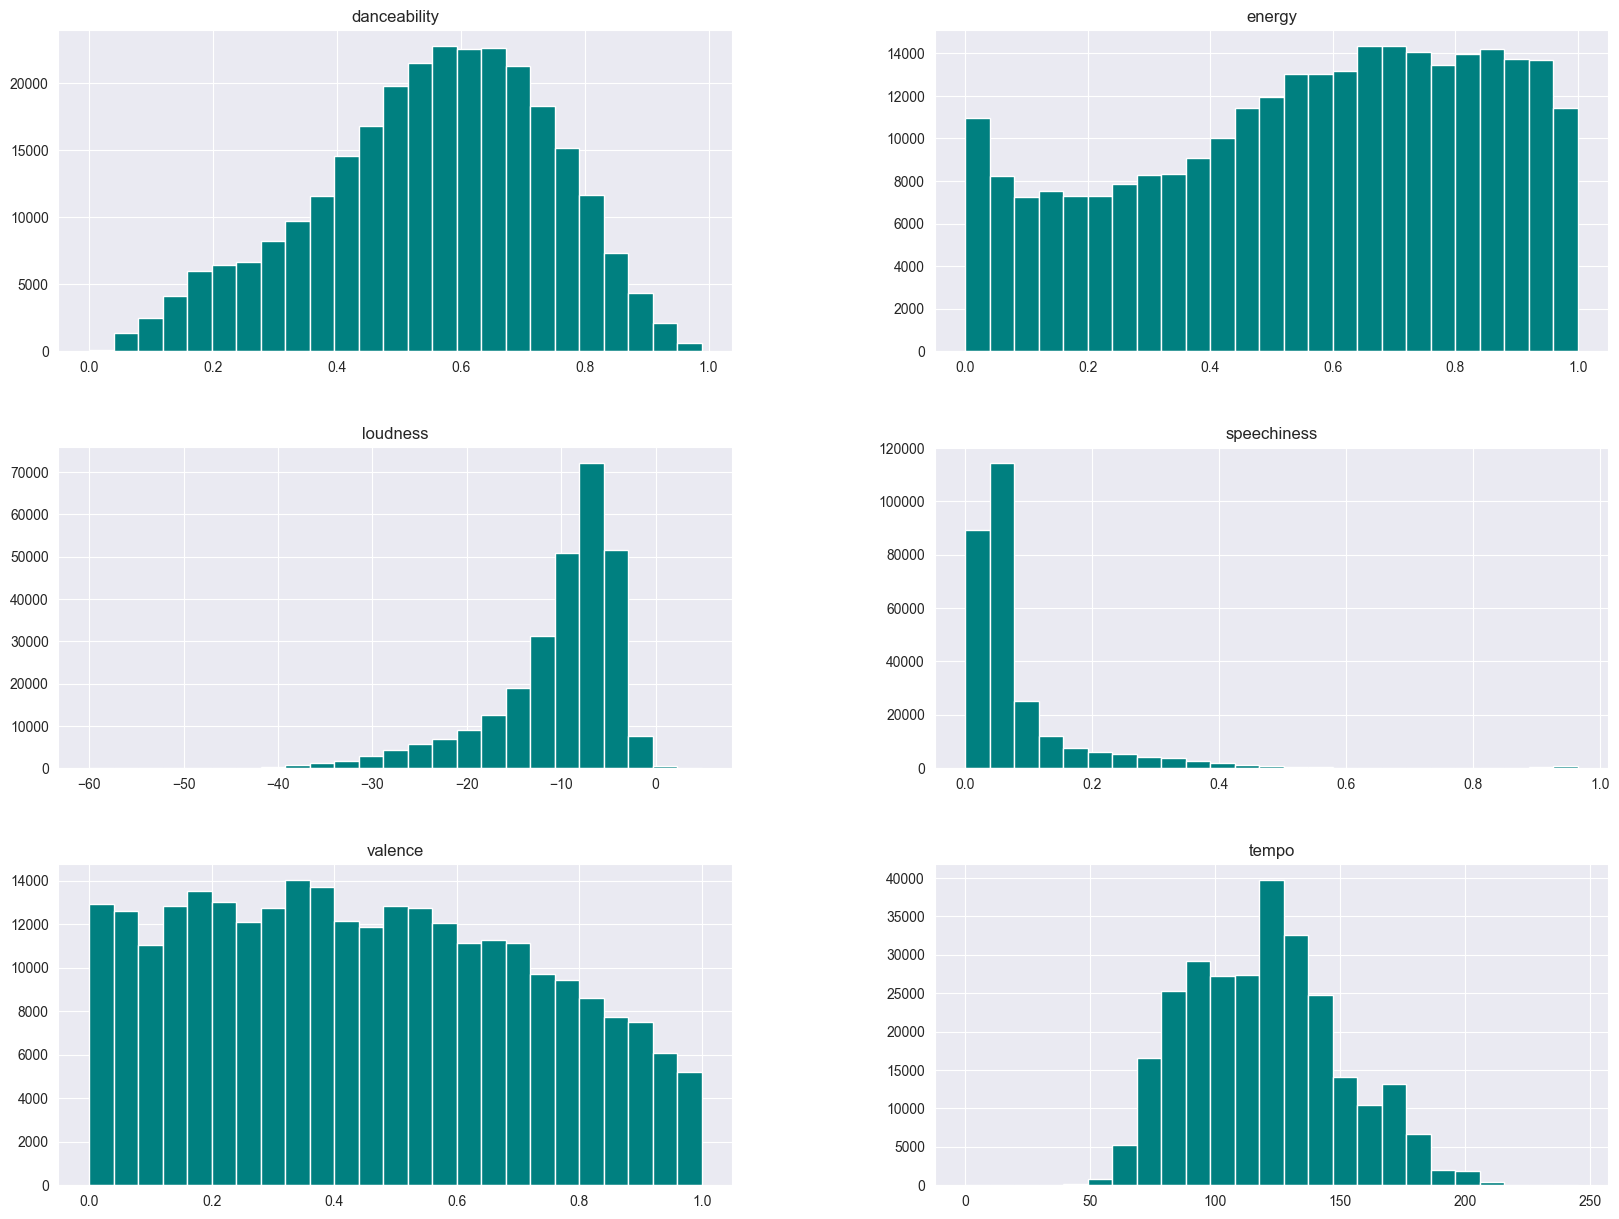

In [4]:
sns.set_style('darkgrid')
columnas_de_interes = datos[['danceability','energy','loudness','speechiness','valence','tempo']]
columnas_de_interes.hist(figsize=(20,15), color='teal', bins=25)

plt.show()

array([[<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'duration_ms'}>],
       [<Axes: title={'center': 'time_signature'}>, <Axes: >, <Axes: >]],
      dtype=object)

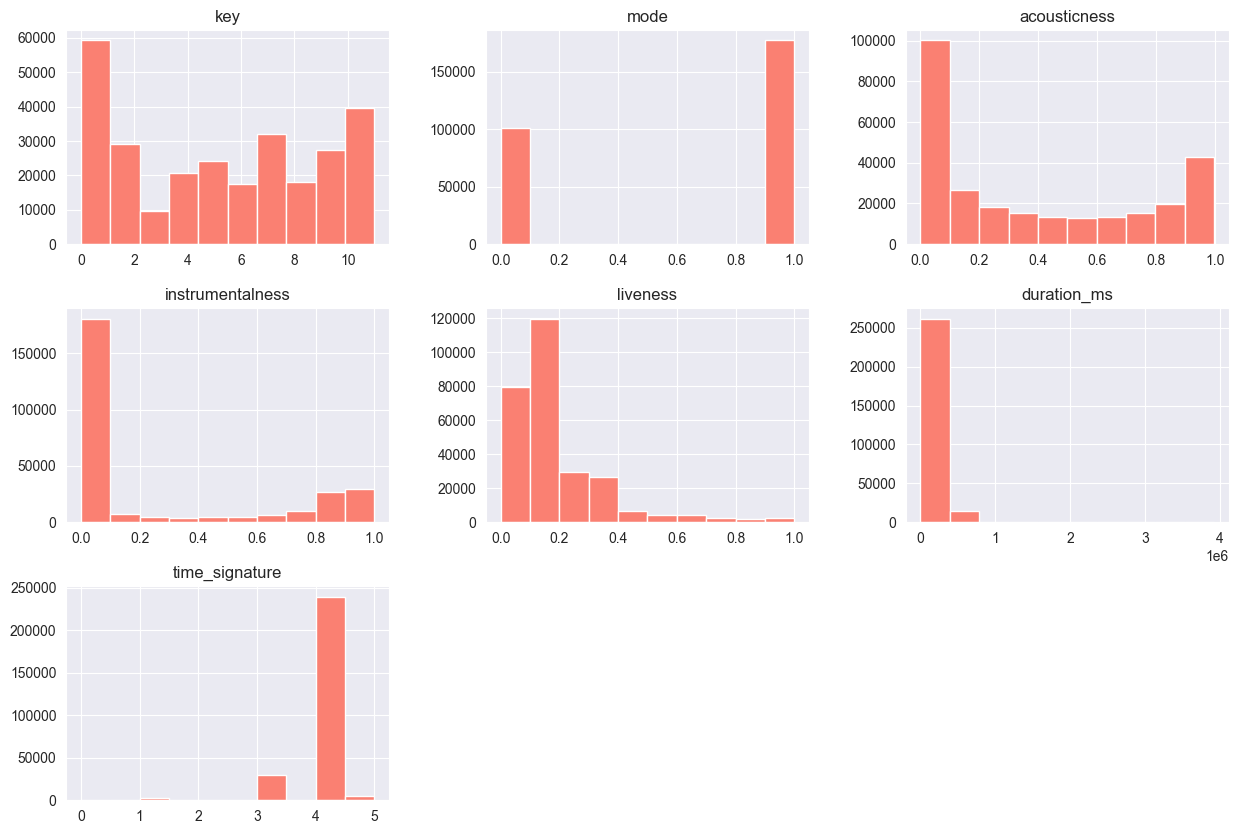

In [5]:
otras_columnas = datos[['key', 'mode', 'acousticness', 'instrumentalness', 'liveness', 'duration_ms', 'time_signature']]
otras_columnas.hist(figsize = (15,10), color='salmon')

## Para danceability)
Debido a que aparente mente presenta una distribucion normal, tomaremos una muestra de 500 datos y aplicaremos la prueba de kolmogorov-Srmirnov para tener resolapdo estadistico de si una distribucion es normal o no.




In [6]:
import scipy.stats as stats
import numpy as np

muestra =  (
    columnas_de_interes['danceability']
    .sample(n=800, random_state=777)
    )

media_muestra = np.mean(muestra)
ds_muestra = np.std(muestra)

ks_stat, ks_p_value = stats.kstest(muestra, 'norm', args=(media_muestra, ds_muestra))

print(f"Estadistico KS: {ks_stat:.4f}")
print(f"Valor p: {ks_p_value:.4f}")
if ks_p_value > 0.05:
    print("Resultado: Los datos SÍ siguen una distribución normal (p > 0.05).")
else:
    print(
        "Resultado: Los datos NO siguen una distribución normal (p <= 0.05)."
    )


Estadistico KS: 0.0453
Valor p: 0.0727
Resultado: Los datos SÍ siguen una distribución normal (p > 0.05).


La observación de que el atributo de *danceability* en Spotify sigue una distribución normal permite inferir que
la mayor parte de las canciones posee un nivel moderado, lo que sugiere que, en general, las personas
pueden mover la cabeza o los pies al escucharlas. Sin embargo, la cola derecha de la distribución indica que solo
una pequeña proporción de canciones alcanza un grado de danceability alto, lo que permitiría a los usuarios
comprometerse plenamente con la danza. Este patrón refuerza la idea de que, aunque la mayoría de las canciones
están diseñadas para ser disfrutadas de manera dinámica, la experiencia de "bailar sin reservas" es una rareza
estadística. Dicho de otra forma, **pocas canciones dentro del catalogo se pueden bailar de forma tradicional**.

### Para speechiness)


Estadistico KS: 0.2548
Valor p: 0.0000
Resultado: Los datos NO siguen una distribucion exponencial (p <= 0.05).


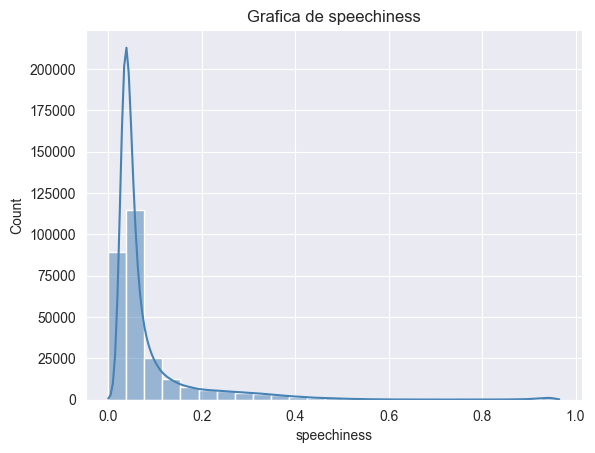

In [7]:
sns.histplot(datos, x='speechiness', color='steelblue', bins=25, kde=True)
plt.title('Grafica de speechiness')

speechines_muestra = datos['speechiness'].sample(n=800, random_state=777)

loc = 0
escala = np.mean(speechines_muestra)

kse_stat, kse_p_value = stats.kstest(speechines_muestra, 'expon', args=(loc,escala))
print(f"Estadistico KS: {kse_stat:.4f}")
print(f"Valor p: {kse_p_value:.4f}")
if kse_p_value > 0.05:
    print("Resultado: Los datos SÍ siguen una distribucion exponencial (p > 0.05).")
else:
    print(
        "Resultado: Los datos NO siguen una distribucion exponencial (p <= 0.05)."
    )


Dada la forma de la variable speechiness, podemos saber que la mayoria de las canciones que tienen voces tienden a cantar en todo momento, sin embargo, la cola del lado derecho nos habla de aquellas donde hay mas precencia de voces hablando que cantando, esto se puede deber a generos como el hiphop o rap, los cuales en su mayoria tienden a hablar en lugar de cantar.

Por otro lado, aun cuando la distribucion tienda a asemejarse a una distribucion exponencial, dada la prueba realizada, podemos conlcuir que **no es una distribucion exponencial**

### Para loudness)




Text(0.5, 1.0, 'Grafica de loudness')

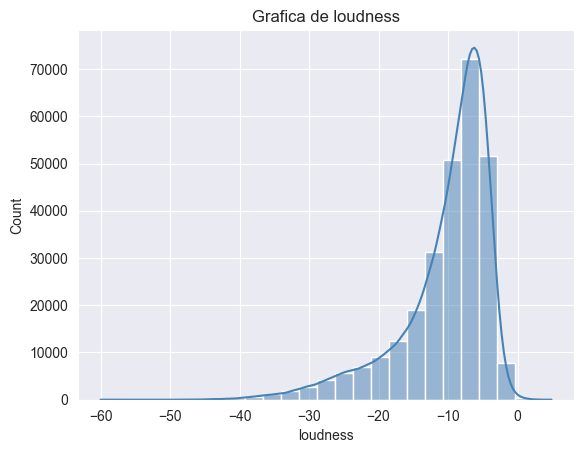

In [8]:
sns.histplot(datos, x='loudness', color='steelblue', bins=25, kde=True)
plt.title('Grafica de loudness')

La variable *loudness* en Spotify presenta una distribución sesgada a la derecha, lo que indica que la mayoría de las canciones tienen un nivel de volumen moderado, sin alcanzar valores extremos. Sin
embargo, la cola derecha de la distribución revela la presencia de un pequeño número de canciones con niveles de volumen cercanos a 0 dB, asociadas principalmente a géneros como el rock, el metal y otros
estilos con alta intensidad sonora. Por otro lado, la cola izquierda —de mayor extensión— refleja la predominancia de géneros más relajados, cuya característica distintiva es un volumen bajo o moderado.
Este patrón resalta la diversidad en los niveles de *loudness* dentro del catálogo musical, evidenciando que, aunque la mayoría de las canciones se ubica en un rango intermedio, existen variaciones
significativas entre géneros que pueden ser aprovechadas en análisis de segmentación, los cuales se abordaran mas adelante

### Comparacion de variables 
A continuan se observaran las relaciones entre las distintas variables para conocer is existen correlaciones importantes entre ellas


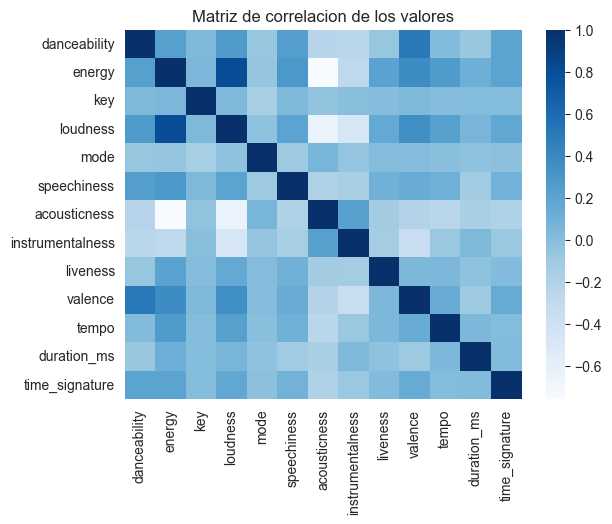

--- Top 5 Correlaciones Positivas ---
loudness     energy          0.813113
valence      danceability    0.506103
             energy          0.370446
             loudness        0.350692
speechiness  energy          0.286920
dtype: float64

--- Top 5 Correlaciones Negativas ---
acousticness      energy             -0.760822
                  loudness           -0.648704
instrumentalness  loudness           -0.477509
valence           instrumentalness   -0.347366
instrumentalness  energy             -0.278347
dtype: float64


In [9]:
def top_correlaciones(datos, n=5):
    matriz_corr = datos.corr(numeric_only=True, method='spearman')
    
    sns.heatmap(matriz_corr, cmap='Blues')
    plt.title('Matriz de correlacion de los valores')
    plt.show()    

    matriz_sin_diag = matriz_corr.where(~np.tril(np.ones(matriz_corr.shape)).astype(bool))
    corr_pairs = matriz_sin_diag.unstack().dropna()
    
    top_positivas = corr_pairs.nlargest(n)
    top_negativas = corr_pairs.nsmallest(n)
    
    return top_positivas, top_negativas

fuertes_positivas, fuertes_negativas = top_correlaciones(datos, n=5)

print("--- Top 5 Correlaciones Positivas ---")
print(fuertes_positivas)
print("\n--- Top 5 Correlaciones Negativas ---")
print(fuertes_negativas)


#### Conclusiones de correlaciones
Despues de obtener las relaciones mas fuertes tanto positivas como negativas, podemos decir lo siguiente.

* loudness - energy)
    * La relacion entre el loudness (volumen) de una cancion estan entrechamente relacionadas puesto que se observa una relacion de 0.81 entre ambas variables, es decir, a mayor volumen, mas energia tendra una cancion

* Valence - dandeability)
    * Otra correlacion importante esta entre valence y danceability. Esta relacion se da debido a que naturalmente, las canciones mas alegres, movidas y bbrillosas tienden a bailarse de forma mas seguida

* Acousticness - energy)
    * Finalmente, la segunda relacion mas significativa entre als variables, es que a menor energia, menos probable es que una cancion sea acustica

## Generos)
Finalmente, para poder verificar si es posible identificar el genero de una cancion basado en sus caracteristicas musicales, se tomaran solamente las variables que refieren a la acustica de una cancion, posteriormente se aplicara un algoritmo de reduccion de dimension para poder graficar los diversos grupos y verificar si es posible identificar diversos generos de canciones dependiendo de sus caracteristicas. Es decir, comprobaremos si es posibble diferenciar a las canciones en grupos basados solamente en caracteristicas objetivas.

In [10]:
columnas_acusticas = datos[['danceability','energy','speechiness','acousticness','instrumentalness','valence','tempo','time_signature']]

Se tomaron las variables anteriores solamente debido a que son las que mas enriquecerian la division, asi mismo, se eliminaron algunas como loudness ya que aunque nos da informacion importante acerca de una cancion, esta estrechamente relacionada con otras variables, es decir, meteria ruido a nuestra informacion

### Reduccion de dimension
A continuacion se realiazra la reduccion de dimension de nuestras variables, la reduccion mas comun es PCA, sin embargo, antes de aplicarla, se realizaran dos pruebas para determinar su eficacia en el conjunto de datos, posteriormente, si PCA resulta no ser apta para los datos, se utilizara algun otro algoritmo.

In [11]:
from factor_analyzer import calculate_kmo

kmo_por_variable, kmo_total = calculate_kmo(columnas_acusticas)
print("--- Prueba KMO ---")
print(f"Índice KMO Total: {kmo_total:.4f}")
if kmo_total >= 0.60:
    print("Resultado: Adecuado. La estructura de datos es compacta para PCA.")
else:
    print("Resultado: Inadecuado (KMO < 0.60). No se recomienda usar PCA.")

--- Prueba KMO ---
Índice KMO Total: 0.6647
Resultado: Adecuado. La estructura de datos es compacta para PCA.


PC1 (34.9%)
PC2 (14.1%)
PC3 (12.5%)
Total (61.6%)


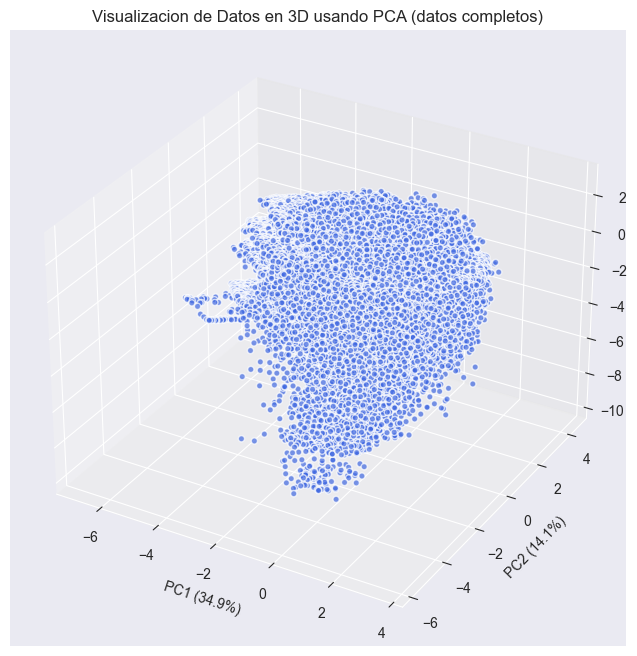

PC1 (34.9%)
PC2 (14.1%)
PC3 (12.5%)
Total (61.6%)


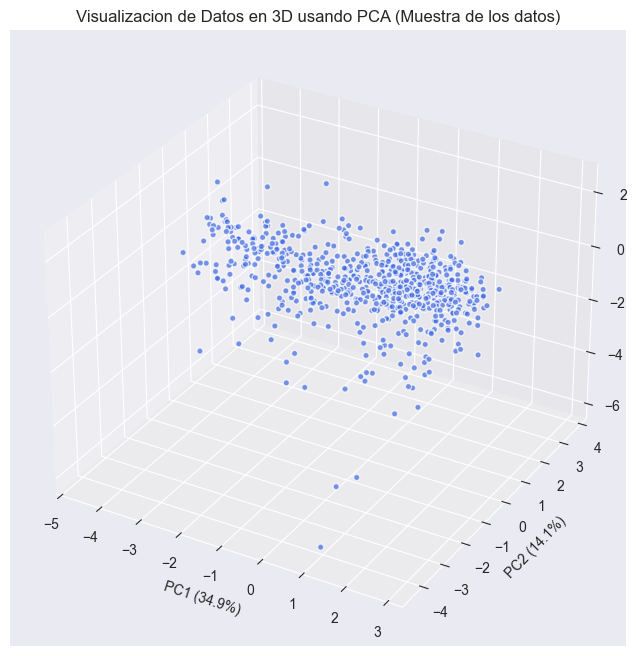

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
pca = PCA(n_components=3)


datos_est = scaler.fit_transform(columnas_acusticas)
datos3d = pca.fit_transform(datos_est)

df_pca_3d = pd.DataFrame(datos3d, columns=["PC1", "PC2", "PC3"])


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(
    df_pca_3d["PC1"],
    df_pca_3d["PC2"],
    df_pca_3d["PC3"],
    c="royalblue",  
    alpha=0.7,  
    edgecolors="w",
)


ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
print(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
print(f"Total ({pca.explained_variance_ratio_[0]*100 + pca.explained_variance_ratio_[1]*100 + pca.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("Visualizacion de Datos en 3D usando PCA (datos completos)")

plt.show()



df_pca_3d_nuevo = df_pca_3d.sample(n=700)


fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(
    df_pca_3d_nuevo["PC1"],
    df_pca_3d_nuevo["PC2"],
    df_pca_3d_nuevo["PC3"],
    c="royalblue",  
    alpha=0.7,  
    edgecolors="w",
)


ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
print(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
print(f"Total ({pca.explained_variance_ratio_[0]*100 + pca.explained_variance_ratio_[1]*100 + pca.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("Visualizacion de Datos en 3D usando PCA (Muestra de los datos)")

plt.show()

In [39]:
pesos_df = pd.DataFrame(
    pca.components_, 
    columns=columnas_acusticas.columns, 
    index=["PC1", "PC2", "PC3"]
)

print("--- Matriz de Pesos  ---")
print(pesos_df)
print("\n" + "="*40 + "\n")

# 2. Extraemos la variable con el peso absoluto más alto para cada PC
print("--- Variable más influyente por Componente ---")
for pc in pesos_df.index:
    # Usamos idxmax() sobre el valor absoluto porque un peso muy negativo (-0.9) 
    # es igual de influyente que uno muy positivo (0.9)
    variable_mas_importante = pesos_df.loc[pc].abs().idxmax()
    valor_peso = pesos_df.loc[pc, variable_mas_importante]
    
    print(f"En el {pc}, la variable con más peso es: '{variable_mas_importante}' (Peso: {valor_peso:.3f})")


--- Matriz de Pesos  ---
     danceability    energy  speechiness  acousticness  instrumentalness  \
PC1      0.383126  0.492417     0.158477     -0.466651         -0.358653   
PC2     -0.463287  0.299670    -0.379716     -0.337389          0.133423   
PC3      0.125267 -0.015329    -0.619746     -0.040946          0.224099   

      valence     tempo  time_signature  
PC1  0.396101  0.201162        0.204615  
PC2 -0.304165  0.568321       -0.065114  
PC3  0.077141 -0.260610        0.688638  


--- Variable más influyente por Componente ---
En el PC1, la variable con más peso es: 'energy' (Peso: 0.492)
En el PC2, la variable con más peso es: 'tempo' (Peso: 0.568)
En el PC3, la variable con más peso es: 'time_signature' (Peso: 0.689)


### Conclusiones
* El algoritmo de reduccion de dimension perdio una cantidad bastante considerable de informacion en ambos casos, solamente estamos refleando un 61.6 y 62 por ciento de la informacion, respectivamente, asi mismo, no es posible localizzar nubes de puntos especificas entre cada grupo. Lo cual sugiere que la falta de informacion nos esta afectando.
* Una explicacion a lo anterior podria ser que el KMO apenas fue aceptable, sin embargo, podria haber sido mejor ( kkmo > 0.8)

### Cambio de enfoque
Debido a que con PCA no logramos encontrar ninguna agrupacion en especifico (cuando cuando visualizamos todo el dataset y una muestra del mismo), ahora se optara por utilizar un algoritmo de reduccion de dimension no lineal, con el fin de poder observar relaciones complejas en un plano


d:\Universidad\DDAADD\Data_Analisis_Spotify\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


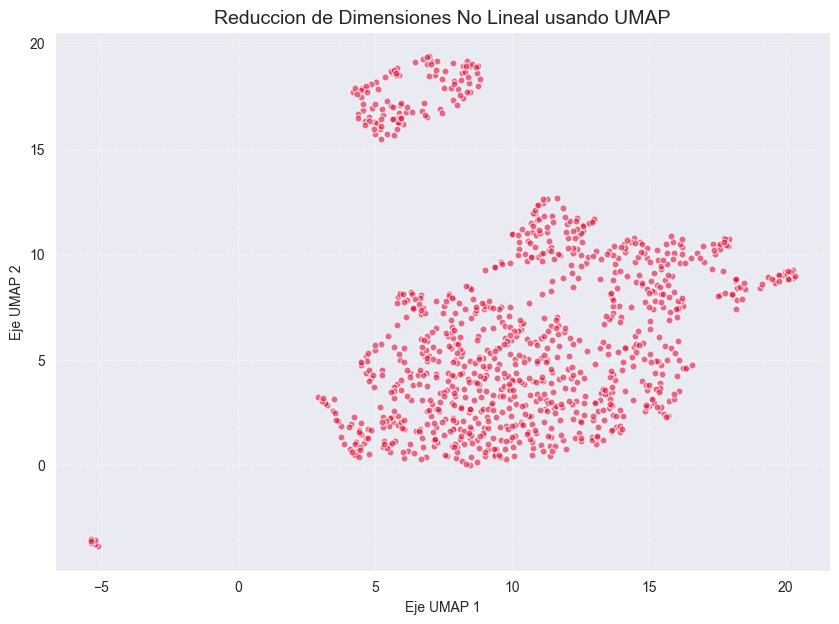

d:\Universidad\DDAADD\Data_Analisis_Spotify\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


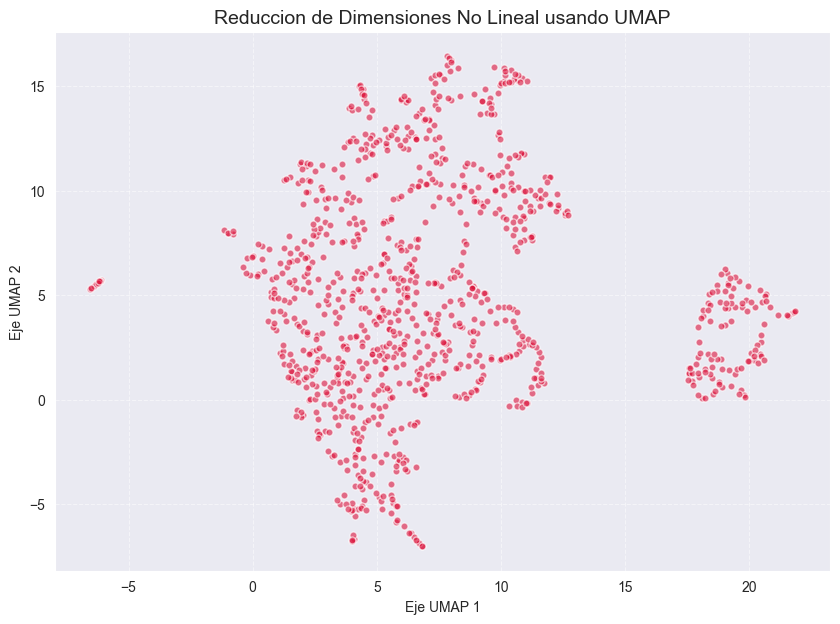

In [36]:
import umap

reducer = umap.UMAP(
    n_neighbors=7,  
    min_dist=0.5,  
    n_components=2,  
    random_state=42,  
)


datos_umap = reducer.fit_transform(datos_est)


df_umap = pd.DataFrame(datos_umap, columns=["UMAP_1", "UMAP_2"])


plt.figure(figsize=(10, 7))
plt.scatter(
    df_umap["UMAP_1"],
    df_umap["UMAP_2"],
    c="crimson",
    alpha=0.6,
    edgecolors="w",
    s=25,  
)

plt.title("Reduccion de Dimensiones No Lineal usando UMAP", fontsize=14)
plt.xlabel("Eje UMAP 1")
plt.ylabel("Eje UMAP 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

import umap

reducer = umap.UMAP(
    n_neighbors=4,  
    min_dist=0.5,  
    n_components=2,  
    random_state=42,  
)


datos_umap = reducer.fit_transform(datos_est)


df_umap = pd.DataFrame(datos_umap, columns=["UMAP_1", "UMAP_2"])


plt.figure(figsize=(10, 7))
plt.scatter(
    df_umap["UMAP_1"],
    df_umap["UMAP_2"],
    c="crimson",
    alpha=0.6,
    edgecolors="w",
    s=25,  
)

plt.title("Reduccion de Dimensiones No Lineal usando UMAP", fontsize=14)
plt.xlabel("Eje UMAP 1")
plt.ylabel("Eje UMAP 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Conclusiones
Tras aplicar la técnica de reducción de dimensionalidad UMAP, se identificaron tres agrupaciones principales dentro de los datos. La primera corresponde a un grupo pequeño y claramente separado del resto de las observaciones. Debido a su posición aislada, es probable que represente contenido atípico, como canciones altamente experimentales, fragmentos de podcast u otros registros que se alejan de las características comunes de una canción convencional. En este sentido, puede considerarse un conjunto de valores atípicos (outliers).

Por otra parte, se observa una agrupación de gran tamaño que concentra la mayor parte de los datos. Este grupo probablemente representa las canciones que podrían catalogarse como tradicionales o convencionales. La amplitud de esta nube puede explicarse por la diversidad inherente de géneros, ritmos y estilos musicales presentes en el conjunto de datos. Aunque estas canciones comparten características suficientes para pertenecer a una misma región del espacio reducido, las diferencias entre géneros generan una dispersión considerable dentro de la agrupación.

Finalmente, se identifica una tercera agrupación de tamaño intermedio, más compacta y bien delimitada. Una posible interpretación es que este grupo corresponda a canciones instrumentales o predominantemente acústicas, es decir, piezas musicales con poca o ninguna presencia de voz. Su separación respecto al grupo principal sugiere que poseen características distintivas que permiten diferenciarlas claramente del resto de las canciones analizadas.


<hr />

## Resolucion de preguntas
1. ¿Existen grupos naturales de canciones con características similares?

   * Sí. A partir de las técnicas de reducción de dimensionalidad se identificaron tres grupos claramente diferenciados, lo que indica la existencia de agrupaciones naturales de canciones con características acústicas similares.

2. ¿Qué características presentan las correlaciones más fuertes?

   * **Loudness - Energy**

     * La correlación más fuerte se observa entre *loudness* y *energy* (0.81). Esto indica que las canciones con mayor volumen percibido suelen presentar una mayor intensidad o dinamismo musical.

   * **Valence - Danceability**

     * También se observa una relación importante entre *valence* y *danceability*. Esto sugiere que las canciones con un carácter más positivo, alegre o animado tienden a ser más aptas para bailar.

   * **Acousticness - Energy**

     * Existe una relación inversa entre *acousticness* y *energy*. En general, las canciones más acústicas suelen presentar menores niveles de intensidad musical.

3. ¿Las canciones con alta danceability también suelen tener alta energy?

   * Sí. Esta relación fue confirmada mediante la correlación de Spearman, mostrando que las canciones más bailables tienden a presentar mayores niveles de intensidad musical.

4. ¿Qué variables explican mejor la variabilidad musical del conjunto de datos?

   * Las variables que mejor explican la variabilidad son *energy*, *tempo* y *time_signature*. La primera refleja la intensidad o dinamismo de una pieza, mientras que las otras dos describen aspectos relacionados con su ritmo y estructura temporal. En conjunto, estas características permiten diferenciar de manera efectiva distintos tipos de canciones, sin importar las notas tocadas.

5. ¿Es posible identificar géneros o estilos únicamente a partir de características acústicas?

   * El análisis permitió distinguir tres grupos principales de canciones a partir de sus características acústicas. Sin embargo, para identificar géneros musicales de forma precisa sería necesario incorporar información adicional, como el género asignado al artista o etiquetas musicales especializadas.

